# SIMPUL Tahap Dua: Kalibrasi Parameter Terverifikasi dan Analisis Kepekaan

Notebook ini melanjutkan pengolahan tahap pertama. Tugasnya satu, yaitu mengganti seluruh
asumsi rancangan pada lapis ketiga dengan angka yang sudah ditelusuri ke sumber resmi, lalu
menguji apakah kesimpulan tahap pertama bertahan.

Pada tahap pertama terdapat tiga besaran yang dipakai tanpa sumber, yaitu jumlah hari
layanan setahun, pangsa ikan dalam nilai bahan baku, dan berat ikan per porsi. Ketiganya
sudah dicatat sebagai keterbatasan. Notebook ini menyelesaikan ketiganya.

Hasil penelusuran mengubah dua hal secara berarti. Pertama, berat ikan per porsi pada
tahap pertama ditetapkan lima puluh gram, sedangkan standar gizi menuntut angka yang jauh
lebih besar. Kedua, jumlah penerima manfaat dan jumlah dapur di Sulawesi Tenggara sudah
diperbarui oleh otoritas perbendaharaan setelah tahap pertama disusun.

Pemodelan ikan juga diperbaiki strukturnya. Pada tahap pertama berat ikan per porsi dan
frekuensi kemunculan menu ikan tercampur dalam satu angka, sehingga tidak dapat diperiksa
secara terpisah. Keduanya kini dipisah, dan pengaruh masing masing diuji dalam kisi dua
dimensi.

Seluruh keluaran tabel dan gambar disusun dalam bahasa Inggris. Penjelasan langkah dan
interpretasi disusun dalam bahasa Indonesia.


## Langkah 0. Menyiapkan lingkungan dan mengambil hasil tahap pertama

Notebook ini membaca berkas arsip keluaran tahap pertama. Berkas tersebut dicari pada
folder Drive, pada direktori kerja, atau diunggah langsung. Dengan cara ini tahap kedua
tidak perlu mengulang perhitungan lapis pertama dan lapis kedua yang tidak berubah.


In [ ]:
import subprocess, sys, os

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "openpyxl>=3.1"], check=False)
subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-liberation"],
               check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("Pemasangan pustaka selesai.")

Pemasangan pustaka selesai.


In [ ]:
import os, re, glob, json, zipfile, shutil, warnings, datetime as dt
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

font_manager._load_fontmanager(try_read_cache=False)
_ada = {f.name for f in font_manager.fontManager.ttflist}
_urut = ["Times New Roman", "Liberation Serif", "Nimbus Roman", "DejaVu Serif"]
FONT = next((f for f in _urut if f in _ada), "serif")

matplotlib.rcParams.update({
    "font.family": "serif", "font.serif": [FONT] + _urut, "font.size": 13,
    "axes.titlesize": 13, "axes.labelsize": 13, "xtick.labelsize": 13,
    "ytick.labelsize": 13, "legend.fontsize": 13, "figure.titlesize": 13,
    "axes.unicode_minus": False, "figure.dpi": 110, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.25,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

WARNA = {"struktural": "#1f4e79", "koordinasi": "#c0504d", "campuran": "#7f7f7f",
         "aksen": "#2e7d32", "netral": "#404040", "muda": "#a6bddb",
         "sorot": "#b8860b"}

print("Huruf visualisasi:", FONT, "| ukuran dasar:", matplotlib.rcParams["font.size"])

Huruf visualisasi: Liberation Serif | ukuran dasar: 13.0


In [ ]:
def siapkan_folder():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        akar = "/content/drive/MyDrive/SIMPUL_Forkestra2026_Tahap2"
        di_colab = True
    except Exception:
        akar = os.path.abspath("./SIMPUL_Forkestra2026_Tahap2")
        di_colab = False
    jalur = {"akar": akar}
    for s in ["01_masukan", "02_tabel", "03_gambar", "04_interpretasi", "05_pustaka"]:
        p = os.path.join(akar, s); os.makedirs(p, exist_ok=True); jalur[s] = p
    return jalur, di_colab

JALUR, DI_COLAB = siapkan_folder()
print("Berjalan di Colab:", DI_COLAB)
print("Folder akar:", JALUR["akar"])

def cari_arsip():
    pola = "SIMPUL_Forkestra2026_hasil_*.zip"
    lokasi = [JALUR["01_masukan"], "/content", os.getcwd(),
              "/content/drive/MyDrive/SIMPUL_Forkestra2026",
              os.path.abspath("./SIMPUL_Forkestra2026"), "/mnt/user-data/uploads"]
    kandidat = []
    for d in lokasi:
        if os.path.isdir(d):
            kandidat += glob.glob(os.path.join(d, pola))
    return sorted(kandidat, key=os.path.getmtime)[-1] if kandidat else None

ARSIP = cari_arsip()
if ARSIP is None and DI_COLAB:
    print("Arsip tahap pertama belum ditemukan. Silakan unggah berkas zip hasil tahap satu.")
    from google.colab import files
    naik = files.upload()
    for nama in naik:
        shutil.move(nama, os.path.join(JALUR["01_masukan"], nama))
    ARSIP = cari_arsip()

if ARSIP is None:
    raise FileNotFoundError("Arsip hasil tahap pertama tidak ditemukan.")

EKSTRAK = os.path.join(JALUR["01_masukan"], "tahap1")
os.makedirs(EKSTRAK, exist_ok=True)
with zipfile.ZipFile(ARSIP) as z:
    z.extractall(EKSTRAK)
print("Arsip tahap pertama:", os.path.basename(ARSIP))

def ambil(pola):
    hit = glob.glob(os.path.join(EKSTRAK, "**", pola), recursive=True)
    return hit[0] if hit else None

T1 = {}
for nama, pola in [("taksonomi", "table1_friction_taxonomy.csv"),
                   ("biaya_friksi", "table2_friction_cost.csv"),
                   ("konektivitas", "table3_directional_connectedness.csv"),
                   ("tangga_nilai", "table6_fishery_value_ladder.csv"),
                   ("ruang", "table7_spatial_mismatch.csv"),
                   ("perikanan", "bersih_perikanan.csv"),
                   ("penduduk", "bersih_penduduk.csv"),
                   ("tongkol", "bersih_tongkol.csv"),
                   ("pihps", "bersih_pihps.csv")]:
    p = ambil(pola)
    T1[nama] = pd.read_csv(p) if p else None
    print("  %-14s %s" % (nama, "termuat" if p else "TIDAK DITEMUKAN"))

p_catatan = ambil("catatan_teknis.json")
CATATAN_T1 = json.load(open(p_catatan, encoding="utf-8")) if p_catatan else {}
print("\nHasil utama tahap pertama:")
for k, v in CATATAN_T1.get("hasil_utama", {}).items():
    print("  %-42s %s" % (k, v))

Mounted at /content/drive
Berjalan di Colab: True
Folder akar: /content/drive/MyDrive/SIMPUL_Forkestra2026_Tahap2
Arsip tahap pertama: SIMPUL_Forkestra2026_hasil_20260821_1623.zip
  taksonomi      termuat
  biaya_friksi   termuat
  konektivitas   termuat
  tangga_nilai   termuat
  ruang          termuat
  perikanan      termuat
  penduduk       termuat
  tongkol        termuat
  pihps          termuat

Hasil utama tahap pertama:
  indeks_konektivitas_total_persen           54.6
  rasio_dominasi_kendari                     1.048
  indeks_ketidaksesuaian_ruang               0.365
  biaya_friksi_struktural_persen             5.3
  premi_pengolahan_kali                      3.68
  pangsa_lokal_skenario_dasar                1.0
  nilai_tertahan_rp                          175956975047.0
  kebutuhan_terhadap_produksi_persen         4.08
  marjin_rantai_pasok_persen                 47.3


## Langkah 1. Menyusun daftar asal usul parameter

Setiap besaran yang dipakai dalam pemodelan dicatat lengkap dengan nilainya, satuannya,
sumbernya, dan derajat keandalannya. Derajat keandalan dibedakan menjadi tiga.

Tingkat pertama adalah angka resmi, yaitu besaran yang tercantum dalam dokumen atau
pernyataan lembaga yang berwenang. Tingkat kedua adalah angka turunan, yaitu besaran yang
dihitung dari angka resmi melalui perhitungan yang dapat ditelusuri. Tingkat ketiga adalah
asumsi rancangan, yaitu besaran yang tidak memiliki rujukan resmi sehingga harus diuji
melalui analisis kepekaan.

Pembedaan ini penting karena kritik yang paling mudah dilontarkan terhadap tulisan ilmiah
berbasis pemodelan adalah bahwa hasilnya bergantung pada asumsi yang dipilih penulis.
Dengan mencantumkan asal usul setiap besaran, pembaca dapat menilai sendiri bagian mana
dari kesimpulan yang kokoh dan bagian mana yang bergantung pada pilihan.


In [ ]:
PARAMETER = [
 # --- struktur biaya program, seluruhnya angka resmi ---
 dict(kode="pagu_porsi_kecil", nilai=13000, satuan="Rp per porsi", tingkat="Resmi",
      sumber="Keputusan Kepala BGN Nomor 401.1 Tahun 2025; Siaran Pers BGN "
             "SIPERS-98/BGN/02/2026",
      catatan="Balita, PAUD, TK, RA, dan SD atau MI kelas satu sampai tiga"),
 dict(kode="pagu_porsi_besar", nilai=15000, satuan="Rp per porsi", tingkat="Resmi",
      sumber="Keputusan Kepala BGN Nomor 401.1 Tahun 2025; Siaran Pers BGN "
             "SIPERS-98/BGN/02/2026",
      catatan="SD atau MI kelas empat ke atas sampai ibu menyusui"),
 dict(kode="bahan_baku_kecil", nilai=8000, satuan="Rp per porsi", tingkat="Resmi",
      sumber="Siaran Pers BGN SIPERS-98/BGN/02/2026",
      catatan="Komponen bahan makanan pada pagu porsi kecil"),
 dict(kode="bahan_baku_besar", nilai=10000, satuan="Rp per porsi", tingkat="Resmi",
      sumber="Siaran Pers BGN SIPERS-98/BGN/02/2026",
      catatan="Komponen bahan makanan pada pagu porsi besar"),
 dict(kode="operasional", nilai=3000, satuan="Rp per porsi", tingkat="Resmi",
      sumber="Siaran Pers BGN SIPERS-98/BGN/02/2026",
      catatan="Listrik, gas, air, insentif relawan, dan biaya pendukung lain"),
 dict(kode="insentif_fasilitas", nilai=2000, satuan="Rp per porsi", tingkat="Resmi",
      sumber="Keputusan Kepala BGN Nomor 401.1 Tahun 2025",
      catatan="Setara Rp6.000.000 per hari dengan asumsi satu dapur melayani 3.000 orang"),
 dict(kode="kapasitas_sppg", nilai=3000, satuan="orang per dapur", tingkat="Resmi",
      sumber="Keputusan Kepala BGN Nomor 401.1 Tahun 2025",
      catatan="Asumsi kapasitas yang dipakai dalam penghitungan insentif fasilitas"),
 dict(kode="pemasok_minimum", nilai=15, satuan="pemasok per dapur", tingkat="Resmi",
      sumber="Badan Gizi Nasional, keterangan pers Mei 2026",
      catatan="Dapur dengan pemasok kurang dari lima belas dapat dikenai penghentian "
              "sementara"),
 # --- hari layanan, resmi berupa kisaran ---
 dict(kode="hari_layanan_min", nilai=240, satuan="hari per tahun", tingkat="Resmi",
      sumber="Kepala BGN, konferensi pers anggaran Agustus 2025",
      catatan="Dua puluh hari layanan per bulan dikalikan dua belas bulan"),
 dict(kode="hari_layanan_maks", nilai=252, satuan="hari per tahun", tingkat="Resmi",
      sumber="Kepala BGN, konferensi pers anggaran Agustus 2025",
      catatan="Dua puluh satu hari layanan per bulan dikalikan dua belas bulan"),
 # --- capaian daerah, angka resmi terbaru ---
 dict(kode="penerima_sultra", nilai=704066, satuan="orang", tingkat="Resmi",
      sumber="Kanwil DJPb Sulawesi Tenggara, posisi 31 Juli 2026",
      catatan="Menggantikan angka 667.305 posisi April 2026 yang dipakai pada tahap satu"),
 dict(kode="sppg_sultra", nilai=282, satuan="unit", tingkat="Resmi",
      sumber="Kanwil DJPb Sulawesi Tenggara, posisi 31 Juli 2026",
      catatan="Tersebar di seluruh tujuh belas kabupaten dan kota"),
 dict(kode="pemasok_sultra", nilai=1969, satuan="pemasok", tingkat="Resmi",
      sumber="Kanwil DJPb Sulawesi Tenggara, posisi 31 Juli 2026",
      catatan="Menggantikan angka 1.222 posisi April 2026"),
 # --- standar gizi, angka resmi ---
 dict(kode="protein_hewani_min", nilai=15, satuan="gram per porsi", tingkat="Resmi",
      sumber="Standar Angka Kecukupan Gizi Kementerian Kesehatan yang dirujuk "
             "Keputusan Kepala BGN Nomor 401.1 Tahun 2025",
      catatan="Protein hewani murni, bukan berat bahan"),
 dict(kode="protein_hewani_maks", nilai=20, satuan="gram per porsi", tingkat="Resmi",
      sumber="Standar Angka Kecukupan Gizi Kementerian Kesehatan yang dirujuk "
             "Keputusan Kepala BGN Nomor 401.1 Tahun 2025",
      catatan="Protein hewani murni, bukan berat bahan"),
 dict(kode="protein_tongkol", nilai=23.2, satuan="gram per 100 gram", tingkat="Resmi",
      sumber="Tabel Komposisi Pangan Indonesia, Kementerian Kesehatan",
      catatan="Kandungan protein ikan tongkol segar pada bagian yang dapat dimakan"),
 # --- turunan ---
 dict(kode="bdd_ikan", nilai=0.80, satuan="rasio", tingkat="Asumsi",
      sumber="Kisaran lazim bagian dapat dimakan ikan laut utuh",
      catatan="Diuji pada analisis kepekaan"),
 dict(kode="gram_ikan_per_porsi", nilai=100, satuan="gram ikan utuh", tingkat="Turunan",
      sumber="Dihitung dari standar protein dibagi kandungan protein dibagi bagian "
             "dapat dimakan",
      catatan="Berlaku hanya pada hari dengan menu ikan, bukan setiap hari"),
 # --- asumsi yang tersisa ---
 dict(kode="frekuensi_menu_ikan", nilai=0.30, satuan="pangsa hari layanan",
      tingkat="Asumsi",
      sumber="Tidak ada ketetapan angka; juknis hanya mengarahkan menu berbasis ikan "
             "menjadi dominan pada daerah penghasil ikan",
      catatan="Diuji pada kisi dua dimensi bersama berat per porsi"),
]

TABEL_PARAMETER = pd.DataFrame(PARAMETER)
P = {d["kode"]: d["nilai"] for d in PARAMETER}

ringkas = TABEL_PARAMETER.rename(columns={
    "kode": "Parameter", "nilai": "Value", "satuan": "Unit",
    "tingkat": "Evidence level", "sumber": "Source", "catatan": "Note"})
print(ringkas[["Parameter", "Value", "Unit", "Evidence level"]].to_string(index=False))
print()
print("Rekapitulasi derajat keandalan:")
print(TABEL_PARAMETER.tingkat.value_counts().to_string())
ringkas.to_csv(os.path.join(JALUR["02_tabel"], "table9_parameter_provenance.csv"),
               index=False)

          Parameter    Value                Unit Evidence level
   pagu_porsi_kecil  13000.0        Rp per porsi          Resmi
   pagu_porsi_besar  15000.0        Rp per porsi          Resmi
   bahan_baku_kecil   8000.0        Rp per porsi          Resmi
   bahan_baku_besar  10000.0        Rp per porsi          Resmi
        operasional   3000.0        Rp per porsi          Resmi
 insentif_fasilitas   2000.0        Rp per porsi          Resmi
     kapasitas_sppg   3000.0     orang per dapur          Resmi
    pemasok_minimum     15.0   pemasok per dapur          Resmi
   hari_layanan_min    240.0      hari per tahun          Resmi
  hari_layanan_maks    252.0      hari per tahun          Resmi
    penerima_sultra 704066.0               orang          Resmi
        sppg_sultra    282.0                unit          Resmi
     pemasok_sultra   1969.0             pemasok          Resmi
 protein_hewani_min     15.0      gram per porsi          Resmi
protein_hewani_maks     20.0      gram p

### Memeriksa kewajaran angka hari layanan

Jumlah hari layanan tidak diumumkan sebagai satu angka tunggal, melainkan sebagai kisaran
dua puluh sampai dua puluh satu hari per bulan selama dua belas bulan. Kewajaran kisaran
itu dapat diperiksa dengan menyusun ulang aritmatika anggaran nasional yang disampaikan
pejabat berwenang, lalu membandingkannya dengan angka yang beliau sebutkan.

Jika hasil penyusunan ulang mendekati angka yang disebutkan, maka kisaran hari layanan
yang dipakai memang konsisten dengan cara lembaga tersebut menghitung anggarannya sendiri.
Pemeriksaan semacam ini lebih kuat daripada sekadar mengutip, karena menguji apakah angka
yang dikutip benar benar dapat dipakai untuk mereproduksi kesimpulan sumbernya.


In [ ]:
PM_NASIONAL = 82_900_000
hari_tengah = (P["hari_layanan_min"] + P["hari_layanan_maks"]) / 2
per_bulan = hari_tengah / 12

rekons = pd.DataFrame([
    dict(Item="Daily outlay", Reconstructed=PM_NASIONAL * P["pagu_porsi_besar"] / 1e12,
         Stated=1.2, Unit="IDR trillion"),
    dict(Item="Monthly outlay",
         Reconstructed=PM_NASIONAL * P["pagu_porsi_besar"] * per_bulan / 1e12,
         Stated=25.0, Unit="IDR trillion"),
    dict(Item="Annual outlay",
         Reconstructed=PM_NASIONAL * P["pagu_porsi_besar"] * hari_tengah / 1e12,
         Stated=300.0, Unit="IDR trillion"),
])
rekons["Deviation (%)"] = (rekons.Reconstructed / rekons.Stated - 1) * 100
print(rekons.round(2).to_string(index=False))

simpangan = rekons["Deviation (%)"].abs().max()
print("\nSimpangan terbesar terhadap angka yang disebutkan: %.1f persen." % simpangan)
if simpangan <= 10:
    print("Kisaran hari layanan konsisten dengan cara lembaga menghitung anggarannya.")
else:
    print("Kisaran hari layanan tidak sepenuhnya konsisten dan perlu ditelusuri lebih jauh.")
rekons.round(2).to_csv(os.path.join(JALUR["02_tabel"],
                       "table10_budget_reconstruction.csv"), index=False)

          Item  Reconstructed  Stated         Unit  Deviation (%)
  Daily outlay           1.24     1.2 IDR trillion           3.63
Monthly outlay          25.49    25.0 IDR trillion           1.97
 Annual outlay         305.90   300.0 IDR trillion           1.97

Simpangan terbesar terhadap angka yang disebutkan: 3.6 persen.
Kisaran hari layanan konsisten dengan cara lembaga menghitung anggarannya.


### Memperbaiki penghitungan berat ikan per porsi

Pada tahap pertama berat ikan per porsi ditetapkan lima puluh gram tanpa dasar. Angka yang
benar diturunkan dari standar gizi melalui tiga langkah.

Langkah pertama membagi target protein hewani dengan kandungan protein ikan tongkol untuk
memperoleh berat daging yang diperlukan.

$$m_{daging} = \frac{p^{target}}{\rho_{protein}}$$

Langkah kedua membagi hasilnya dengan bagian yang dapat dimakan untuk memperoleh berat ikan
utuh yang harus dibeli, karena kepala, tulang, dan isi perut ikut tertimbang saat pembelian
namun tidak ikut termakan.

$$m_{utuh} = \frac{m_{daging}}{\theta_{BDD}}$$

Langkah ketiga memisahkan berat per porsi dari frekuensi kemunculan menu ikan. Kebutuhan
ikan setahun adalah hasil kali jumlah penerima, jumlah hari layanan, frekuensi menu ikan,
dan berat ikan utuh per porsi.

$$Q_{ikan} = N \times H \times f \times m_{utuh}$$

Pemisahan ini penting karena kedua besaran memiliki sifat yang berbeda. Berat per porsi
ditentukan standar gizi sehingga hampir tidak dapat ditawar, sedangkan frekuensi menu ikan
adalah pilihan kebijakan yang justru menjadi pokok pembahasan tulisan ini.


In [ ]:
m_daging_min = P["protein_hewani_min"] / (P["protein_tongkol"] / 100)
m_daging_maks = P["protein_hewani_maks"] / (P["protein_tongkol"] / 100)
m_utuh_min = m_daging_min / P["bdd_ikan"]
m_utuh_maks = m_daging_maks / P["bdd_ikan"]

TABEL_GRAM = pd.DataFrame([
    dict(Step="Animal protein target", Low=P["protein_hewani_min"],
         High=P["protein_hewani_maks"], Unit="g protein"),
    dict(Step="Edible flesh required", Low=m_daging_min, High=m_daging_maks,
         Unit="g flesh"),
    dict(Step="Whole fish purchased", Low=m_utuh_min, High=m_utuh_maks,
         Unit="g whole fish"),
])
print(TABEL_GRAM.round(1).to_string(index=False))
print()
print("Nilai yang dipakai dalam pemodelan: %d gram ikan utuh per porsi menu ikan."
      % P["gram_ikan_per_porsi"])
print("Nilai yang dipakai pada tahap pertama: 50 gram, yaitu %.1f kali lebih rendah "
      "daripada batas bawah standar." % (m_utuh_min / 50))
TABEL_GRAM.round(1).to_csv(os.path.join(JALUR["02_tabel"],
                           "table11_portion_derivation.csv"), index=False)

                 Step  Low  High         Unit
Animal protein target 15.0  20.0    g protein
Edible flesh required 64.7  86.2      g flesh
 Whole fish purchased 80.8 107.8 g whole fish

Nilai yang dipakai dalam pemodelan: 100 gram ikan utuh per porsi menu ikan.
Nilai yang dipakai pada tahap pertama: 50 gram, yaitu 1.6 kali lebih rendah daripada batas bawah standar.


## Langkah 2. Analisis kepekaan dua dimensi

Dua besaran masih menyimpan ketidakpastian, yaitu berat ikan per porsi yang bergantung pada
bagian yang dapat dimakan, dan frekuensi kemunculan menu ikan yang merupakan pilihan
kebijakan. Keduanya diuji bersama dalam bentuk kisi.

Pertanyaan yang dijawab bukan berapa nilai yang benar, melainkan apakah ada kombinasi nilai
yang masuk akal yang dapat membalik kesimpulan. Kesimpulan tahap pertama menyatakan bahwa
kapasitas pasokan bukan kendala yang mengikat. Kesimpulan itu terbantah apabila terdapat
kombinasi wajar yang membuat kebutuhan ikan program melampaui kemampuan produksi provinsi.


In [ ]:
perikanan = T1["perikanan"]
tahun_ikan = int(perikanan.dropna(subset=["produksi_ton"]).tahun.max())
PRODUKSI_TOTAL = float(perikanan[perikanan.tahun == tahun_ikan].produksi_ton.sum())
print("Produksi perikanan tangkap laut Sulawesi Tenggara tahun %d: %s ton"
      % (tahun_ikan, format(PRODUKSI_TOTAL, ",.2f")))

def kebutuhan_ikan(freq, gram_utuh, hari, penerima=None):
    penerima = penerima or P["penerima_sultra"]
    return penerima * hari * freq * (gram_utuh / 1000.0) / 1000.0   # ton

FREKUENSI = [0.20, 0.30, 0.40, 0.50, 0.60]
GRAM = [80, 90, 100, 110, 120]
hari_tengah = (P["hari_layanan_min"] + P["hari_layanan_maks"]) / 2

KISI = pd.DataFrame(
    [[kebutuhan_ikan(f, g, hari_tengah) / PRODUKSI_TOTAL * 100 for g in GRAM]
     for f in FREKUENSI],
    index=["%d%%" % (f * 100) for f in FREKUENSI],
    columns=["%d g" % g for g in GRAM])
KISI.index.name = "Fish menu frequency"
print("\nKebutuhan ikan program sebagai persentase produksi tangkap provinsi:")
print(KISI.round(2).to_string())
print("\nNilai tertinggi pada seluruh kisi: %.2f persen." % KISI.values.max())
if KISI.values.max() < 100:
    print("Tidak ada kombinasi wajar yang membuat kapasitas pasokan menjadi kendala.")
KISI.round(2).to_csv(os.path.join(JALUR["02_tabel"], "table12_sensitivity_grid.csv"))

KISI_TON = pd.DataFrame(
    [[kebutuhan_ikan(f, g, hari_tengah) for g in GRAM] for f in FREKUENSI],
    index=["%d%%" % (f * 100) for f in FREKUENSI],
    columns=["%d g" % g for g in GRAM])
KISI_TON.index.name = "Fish menu frequency"
print("\nKebutuhan ikan program dalam ton per tahun:")
print(KISI_TON.round(0).to_string())

Produksi perikanan tangkap laut Sulawesi Tenggara tahun 2018: 204,364.76 ton

Kebutuhan ikan program sebagai persentase produksi tangkap provinsi:
                     80 g  90 g  100 g  110 g  120 g
Fish menu frequency                                 
20%                  1.36  1.53   1.70   1.86   2.03
30%                  2.03  2.29   2.54   2.80   3.05
40%                  2.71  3.05   3.39   3.73   4.07
50%                  3.39  3.81   4.24   4.66   5.09
60%                  4.07  4.58   5.09   5.59   6.10

Nilai tertinggi pada seluruh kisi: 6.10 persen.
Tidak ada kombinasi wajar yang membuat kapasitas pasokan menjadi kendala.

Kebutuhan ikan program dalam ton per tahun:
                       80 g    90 g    100 g    110 g    120 g
Fish menu frequency                                           
20%                  2771.0  3118.0   3464.0   3810.0   4157.0
30%                  4157.0  4676.0   5196.0   5716.0   6235.0
40%                  5542.0  6235.0   6928.0   7621.0   8314.0

### Gambar kesembilan, peta kepekaan kebutuhan terhadap kapasitas

Peta panas menampilkan seluruh kisi. Angka pada setiap sel adalah kebutuhan ikan program
sebagai persentase produksi perikanan tangkap provinsi. Sel yang ditandai adalah kombinasi
yang dipakai sebagai skenario dasar.

Pembacaannya sederhana. Jika seluruh sel berada jauh di bawah seratus persen, maka
kesimpulan bahwa kapasitas bukan kendala tidak bergantung pada pilihan asumsi.


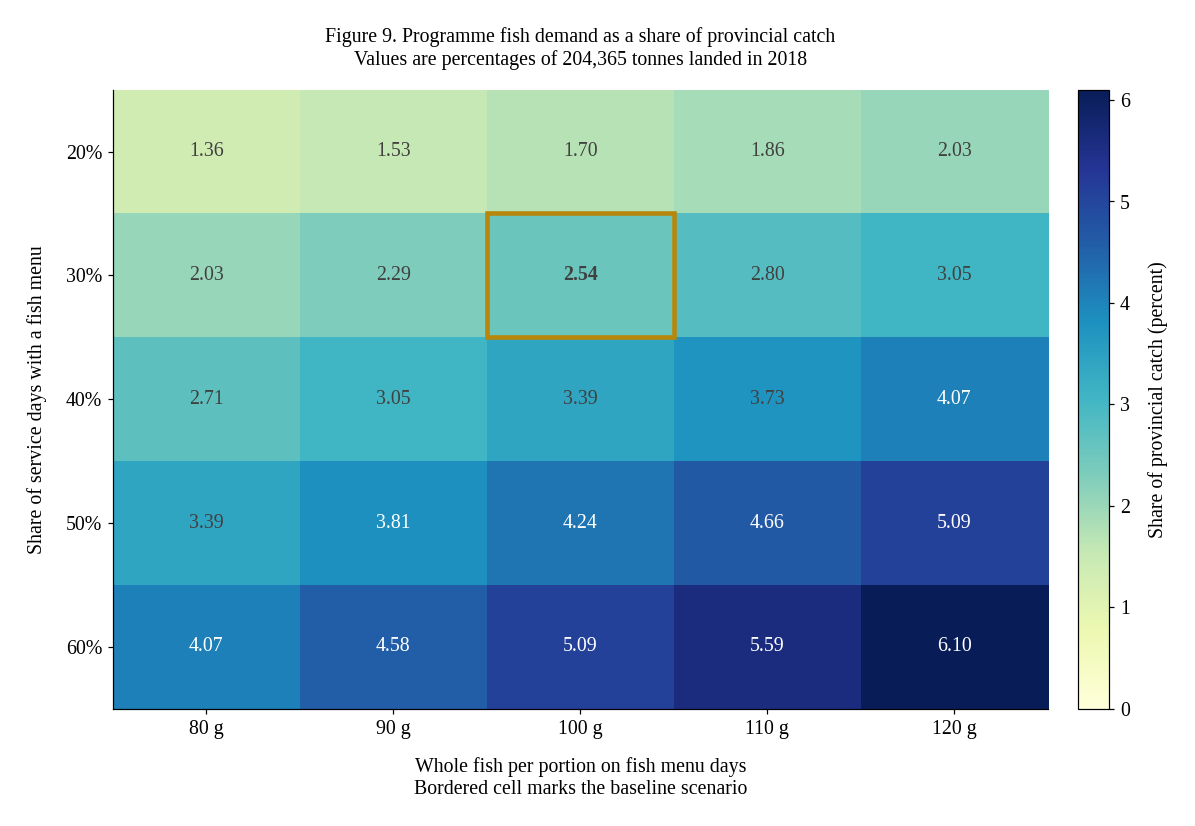

In [ ]:
fig, sb = plt.subplots(figsize=(10.8, 7.4))
gbr = sb.imshow(KISI.values, cmap="YlGnBu", aspect="auto", vmin=0)

sb.set_xticks(np.arange(len(GRAM)))
sb.set_yticks(np.arange(len(FREKUENSI)))
sb.set_xticklabels(KISI.columns)
sb.set_yticklabels(KISI.index)
sb.set_ylabel("Share of service days with a fish menu", labelpad=12)
sb.set_title("Figure 9. Programme fish demand as a share of provincial catch\n"
             "Values are percentages of %s tonnes landed in %d"
             % (format(PRODUKSI_TOTAL, ",.0f"), tahun_ikan), pad=16)
sb.grid(False)

i_dasar = FREKUENSI.index(P["frekuensi_menu_ikan"])
j_dasar = GRAM.index(P["gram_ikan_per_porsi"])
for i in range(len(FREKUENSI)):
    for j in range(len(GRAM)):
        v = KISI.values[i, j]
        tebal = "bold" if (i == i_dasar and j == j_dasar) else "normal"
        sb.text(j, i, "%.2f" % v, ha="center", va="center", fontsize=13,
                fontweight=tebal,
                color="white" if v > KISI.values.max() * 0.62 else WARNA["netral"])
sb.add_patch(matplotlib.patches.Rectangle((j_dasar - 0.5, i_dasar - 0.5), 1, 1,
             fill=False, edgecolor=WARNA["sorot"], linewidth=3.0, zorder=5))

bar = fig.colorbar(gbr, ax=sb, fraction=0.045, pad=0.03)
bar.set_label("Share of provincial catch (percent)", labelpad=12, fontsize=13)
bar.ax.tick_params(labelsize=13)
sb.set_xlabel("Whole fish per portion on fish menu days\n"
              "Bordered cell marks the baseline scenario", labelpad=12)
plt.tight_layout()
fig.savefig(os.path.join(JALUR["03_gambar"], "figure9_sensitivity_grid.png"))
plt.show()

## Langkah 3. Kepadatan pemasok sebagai ukuran keandalan pasokan

Badan Gizi Nasional menetapkan bahwa dapur dengan pemasok kurang dari lima belas dapat
dikenai penghentian sementara. Ketentuan itu memperlakukan jumlah pemasok sebagai ukuran
ketahanan, karena dapur yang bergantung pada sedikit pemasok akan berhenti berproduksi
begitu satu pemasok gagal mengirim.

Data provinsi memungkinkan penghitungan rasio pemasok terhadap dapur. Rasio ini tidak sama
dengan jumlah pemasok per dapur, karena satu pemasok dapat melayani lebih dari satu dapur.
Yang dapat dihitung secara sah adalah berapa banyak dapur yang harus dilayani setiap
pemasok agar ambang lima belas terpenuhi. Semakin besar angka itu, semakin tipis basis
pemasok yang tersedia dan semakin rapuh rantai pasoknya.


In [ ]:
POSISI = [
    dict(Period="April 2026", Suppliers=1222, Kitchens=273, Beneficiaries=667305),
    dict(Period="July 2026", Suppliers=P["pemasok_sultra"], Kitchens=P["sppg_sultra"],
         Beneficiaries=P["penerima_sultra"]),
]
PASOK = pd.DataFrame(POSISI)
PASOK["Suppliers per kitchen"] = PASOK.Suppliers / PASOK.Kitchens
PASOK["Kitchens per supplier to meet threshold"] = (
    P["pemasok_minimum"] / PASOK["Suppliers per kitchen"])
PASOK["Beneficiaries per kitchen"] = PASOK.Beneficiaries / PASOK.Kitchens
PASOK["Capacity utilisation"] = PASOK["Beneficiaries per kitchen"] / P["kapasitas_sppg"]
print(PASOK.round(2).to_string(index=False))
PASOK.round(2).to_csv(os.path.join(JALUR["02_tabel"],
                      "table13_supplier_density.csv"), index=False)

akhir = PASOK.iloc[-1]
print()
print("Rasio pemasok terhadap dapur pada posisi terakhir: %.2f."
      % akhir["Suppliers per kitchen"])
print("Ambang yang ditetapkan: %d pemasok per dapur." % P["pemasok_minimum"])
print("Agar ambang terpenuhi, setiap pemasok harus melayani rata rata %.1f dapur."
      % akhir["Kitchens per supplier to meet threshold"])
print("Pemanfaatan kapasitas dapur: %.1f persen dari kapasitas rancangan %s orang."
      % (akhir["Capacity utilisation"] * 100, format(P["kapasitas_sppg"], ",")))
pertumbuhan_pemasok = PASOK.Suppliers.iloc[-1] / PASOK.Suppliers.iloc[0] - 1
pertumbuhan_dapur = PASOK.Kitchens.iloc[-1] / PASOK.Kitchens.iloc[0] - 1
print()
print("Antara April dan Juli 2026 jumlah pemasok tumbuh %.1f persen sedangkan jumlah "
      "dapur tumbuh %.1f persen." % (pertumbuhan_pemasok * 100, pertumbuhan_dapur * 100))
if pertumbuhan_pemasok > pertumbuhan_dapur:
    print("Basis pemasok tumbuh lebih cepat daripada jumlah dapur, sehingga kepadatan "
          "pemasok membaik meskipun masih di bawah ambang.")
else:
    print("Jumlah dapur tumbuh lebih cepat daripada basis pemasok, sehingga kepadatan "
          "pemasok memburuk.")

    Period  Suppliers  Kitchens  Beneficiaries  Suppliers per kitchen  Kitchens per supplier to meet threshold  Beneficiaries per kitchen  Capacity utilisation
April 2026       1222       273         667305                   4.48                                     3.35                    2444.34                  0.81
 July 2026       1969       282         704066                   6.98                                     2.15                    2496.69                  0.83

Rasio pemasok terhadap dapur pada posisi terakhir: 6.98.
Ambang yang ditetapkan: 15 pemasok per dapur.
Agar ambang terpenuhi, setiap pemasok harus melayani rata rata 2.1 dapur.
Pemanfaatan kapasitas dapur: 83.2 persen dari kapasitas rancangan 3,000 orang.

Antara April dan Juli 2026 jumlah pemasok tumbuh 61.1 persen sedangkan jumlah dapur tumbuh 3.3 persen.
Basis pemasok tumbuh lebih cepat daripada jumlah dapur, sehingga kepadatan pemasok membaik meskipun masih di bawah ambang.


## Langkah 4. Menjalankan ulang alokasi dengan parameter terverifikasi

Model pemrograman linear pada tahap pertama dijalankan ulang tanpa perubahan bentuk, hanya
dengan mengganti nilai parameternya. Yang berubah adalah jumlah penerima, jumlah hari
layanan, dan cara menghitung kebutuhan ikan yang kini memisahkan berat per porsi dari
frekuensi menu.

Sebaran kebutuhan antarkabupaten tetap didekati dengan pangsa penduduk, dan kapasitas
pasokan tetap diambil dari pola sebaran produksi perikanan tangkap. Biaya perpindahan tetap
diturunkan dari tarif friksi hasil lapis pertama.


In [ ]:
from scipy.optimize import linprog

GUGUS = {"Buton": "island", "Muna": "island", "Wakatobi": "island",
         "Buton Utara": "island", "Konawe Kepulauan": "island",
         "Muna Barat": "island", "Buton Tengah": "island",
         "Buton Selatan": "island", "Baubau": "island",
         "Konawe": "mainland", "Kolaka": "mainland", "Konawe Selatan": "mainland",
         "Bombana": "mainland", "Kolaka Utara": "mainland", "Konawe Utara": "mainland",
         "Kolaka Timur": "mainland", "Kendari": "mainland"}

penduduk = T1["penduduk"].set_index("wilayah")["penduduk"]
produksi = (perikanan[perikanan.tahun == tahun_ikan].set_index("wilayah")["produksi_ton"])

RUANG = pd.DataFrame({"population": penduduk}).join(produksi.rename("catch_tonnes"))
RUANG["catch_tonnes"] = RUANG["catch_tonnes"].fillna(0.0)
RUANG["demand_share"] = RUANG.population / RUANG.population.sum()
RUANG["supply_share"] = RUANG.catch_tonnes / RUANG.catch_tonnes.sum()
RUANG["mismatch"] = RUANG.supply_share - RUANG.demand_share
RUANG["cluster"] = [GUGUS.get(w, "mainland") for w in RUANG.index]

KEBUTUHAN_DASAR = kebutuhan_ikan(P["frekuensi_menu_ikan"], P["gram_ikan_per_porsi"],
                                 hari_tengah)
RUANG["demand_tonnes"] = RUANG.demand_share * KEBUTUHAN_DASAR

harga_produsen = T1["tongkol"]
HARGA_LOKAL = float(harga_produsen[harga_produsen.level_harga == "produsen"]
                    .harga_rp_kg.mean())
biaya_friksi = T1["biaya_friksi"].set_index("Commodity")
FRIKSI_PCT = float(biaya_friksi.loc[biaya_friksi["Permanent share"] >= 0.5,
                                    "Structural friction (% of price)"].mean())
TARIF_FRIKSI = HARGA_LOKAL * FRIKSI_PCT / 100.0
PREMI_LUAR, LIPAT_GUGUS, LIPAT_LUAR = 0.15, 2.0, 3.0
HARGA_LUAR = HARGA_LOKAL * (1 + PREMI_LUAR)

wil = list(RUANG.index); n = len(wil); gugus = RUANG.cluster.to_dict()

def selesaikan(phi, kebutuhan=None):
    d = (RUANG.demand_share * kebutuhan).values if kebutuhan is not None \
        else RUANG.demand_tonnes.values
    biaya = []
    for j in wil:
        for k in wil:
            tambah = 0.0 if j == k else TARIF_FRIKSI * (
                1.0 if gugus[j] == gugus[k] else LIPAT_GUGUS)
            biaya.append((HARGA_LOKAL + tambah) * 1000.0)
    biaya += [(HARGA_LUAR + TARIF_FRIKSI * LIPAT_LUAR) * 1000.0] * n
    c = np.array(biaya, float)
    Aeq = np.zeros((n, n * n + n))
    for k in range(n):
        for j in range(n):
            Aeq[k, j * n + k] = 1.0
        Aeq[k, n * n + k] = 1.0
    Aub = np.zeros((n, n * n + n))
    for j in range(n):
        for k in range(n):
            Aub[j, j * n + k] = 1.0
    bub = RUANG.catch_tonnes.values * phi
    r = linprog(c, A_ub=Aub, b_ub=bub, A_eq=Aeq, b_eq=d.astype(float),
                bounds=[(0, None)] * (n * n + n), method="highs")
    if not r.success:
        return None
    X = r.x[:n * n].reshape(n, n); Z = r.x[n * n:]
    lokal, total = X.sum(), X.sum() + Z.sum()
    return dict(phi=phi, ton_lokal=lokal, ton_luar=Z.sum(),
                pangsa_lokal=lokal / total if total else np.nan,
                nilai_tertahan=lokal * HARGA_LOKAL * 1000.0, biaya=r.fun, X=X)

RASIO = KEBUTUHAN_DASAR / PRODUKSI_TOTAL
print("Kebutuhan ikan skenario dasar: %s ton, setara %.2f persen produksi provinsi."
      % (format(KEBUTUHAN_DASAR, ",.0f"), RASIO * 100))
print("Tarif friksi dari lapis pertama: Rp%s per kilogram (%.2f persen harga)."
      % (format(TARIF_FRIKSI, ",.0f"), FRIKSI_PCT))
print()

SKEN = []
for phi in [0.005, 0.010, 0.015, 0.020, 0.025, 0.030, 0.050]:
    r = selesaikan(phi)
    if r:
        SKEN.append({k: v for k, v in r.items() if k != "X"})
TABEL14 = pd.DataFrame(SKEN).rename(columns={
    "phi": "Absorption cap", "ton_lokal": "Local sourcing (tonnes)",
    "ton_luar": "Outside sourcing (tonnes)", "pangsa_lokal": "Local share",
    "nilai_tertahan": "Value retained (IDR)", "biaya": "Total cost (IDR)"})
print(TABEL14.round(3).to_string(index=False))
TABEL14.round(3).to_csv(os.path.join(JALUR["02_tabel"],
                        "table14_allocation_recalibrated.csv"), index=False)

# Batas serapan dasar dipilih tepat di atas titik jenuh, yaitu titik terkecil yang
# sudah memenuhi seluruh kebutuhan dari dalam provinsi. Memilih batas di bawah titik
# jenuh akan membuat hasilnya mencerminkan kekurangan yang sengaja dibuat, bukan
# keadaan yang hendak dianalisis.
jenuh = TABEL14[TABEL14["Local share"] >= 0.999]
BATAS_DASAR = float(jenuh["Absorption cap"].min()) if len(jenuh) else 0.05
DASAR = selesaikan(BATAS_DASAR)

ANG_BAHAN_MIN = P["penerima_sultra"] * P["bahan_baku_kecil"] * hari_tengah
ANG_BAHAN_MAK = P["penerima_sultra"] * P["bahan_baku_besar"] * hari_tengah
print()
print("Titik jenuh serapan: %.1f persen produksi kabupaten." % (BATAS_DASAR * 100))
print("Anggaran bahan baku setahun : Rp%.3f sampai %.3f triliun"
      % (ANG_BAHAN_MIN / 1e12, ANG_BAHAN_MAK / 1e12))
print("Skenario dasar pada titik jenuh:")
print("  Pasokan setempat  : %s ton (%.1f persen kebutuhan)"
      % (format(DASAR["ton_lokal"], ",.0f"), DASAR["pangsa_lokal"] * 100))
print("  Nilai ke produsen : Rp%s (%.3f triliun)"
      % (format(DASAR["nilai_tertahan"], ",.0f"), DASAR["nilai_tertahan"] / 1e12))

Kebutuhan ikan skenario dasar: 5,196 ton, setara 2.54 persen produksi provinsi.
Tarif friksi dari lapis pertama: Rp1,117 per kilogram (5.29 persen harga).

 Absorption cap  Local sourcing (tonnes)  Outside sourcing (tonnes)  Local share  Value retained (IDR)  Total cost (IDR)
          0.005                 1021.824                   4174.183        0.197          2.155500e+10      1.368030e+11
          0.010                 2043.648                   3152.359        0.393          4.311001e+10      1.303936e+11
          0.015                 3065.471                   2130.536        0.590          6.466501e+10      1.242316e+11
          0.020                 4087.295                   1108.712        0.787          8.622002e+10      1.189419e+11
          0.025                 5109.119                     86.888        0.983          1.077750e+11      1.137099e+11
          0.030                 5196.007                      0.000        1.000          1.096079e+11      1.125402e+

## Langkah 5. Memeriksa konsistensi asumsi tahap pertama

Tahap pertama melaporkan adanya marjin rantai pasok sebesar empat puluh tujuh persen antara
anggaran ikan dan nilai yang sampai ke produsen. Angka itu diperoleh dengan mengalikan
anggaran bahan baku dengan asumsi pangsa ikan sebesar dua puluh lima persen, lalu
menguranginya dengan nilai pembelian pada harga produsen.

Pemeriksaan ulang menunjukkan bahwa dua asumsi yang dipakai untuk membentuk angka tersebut
saling bertentangan. Pangsa ikan dalam anggaran dan frekuensi kemunculan menu ikan tidak
dapat dipilih bebas satu sama lain, karena keduanya terikat oleh harga ikan dan berat porsi.

Hubungan yang mengikat keduanya adalah sebagai berikut. Nilai ikan per porsi pada hari
menu ikan sama dengan berat porsi dikalikan harga per kilogram. Nilai rata rata sepanjang
seluruh hari layanan adalah nilai tersebut dikalikan frekuensi. Pangsa terhadap anggaran
bahan baku adalah nilai rata rata dibagi anggaran bahan baku per porsi.

$$s_{ikan} = \frac{f \times m_{utuh} \times P_{produsen}}{B_{bahan\ baku}}$$

Karena keempat besaran di ruas kanan sudah tertentu, pangsa ikan bukan besaran yang boleh
diasumsikan. Ia harus dihitung. Sel berikut menghitungnya, lalu memeriksa frekuensi menu
ikan yang tersirat apabila pangsa dua puluh lima persen dipaksakan.


In [ ]:
nilai_ikan_per_porsi = (P["gram_ikan_per_porsi"] / 1000.0) * HARGA_LOKAL
nilai_rata_rata = P["frekuensi_menu_ikan"] * nilai_ikan_per_porsi
PANGSA_IKAN_TURUNAN = nilai_rata_rata / P["bahan_baku_kecil"]

PANGSA_LAMA = 0.25
frekuensi_tersirat = PANGSA_LAMA * P["bahan_baku_kecil"] / nilai_ikan_per_porsi

KONSISTENSI = pd.DataFrame([
    dict(Quantity="Fish value per fish-menu portion",
         Value=nilai_ikan_per_porsi, Unit="IDR per portion", Basis="Derived"),
    dict(Quantity="Fish value averaged over all service days",
         Value=nilai_rata_rata, Unit="IDR per portion", Basis="Derived"),
    dict(Quantity="Implied fish share of ingredient budget",
         Value=PANGSA_IKAN_TURUNAN * 100, Unit="percent", Basis="Derived"),
    dict(Quantity="Fish share assumed in stage one",
         Value=PANGSA_LAMA * 100, Unit="percent", Basis="Assumed"),
    dict(Quantity="Fish menu frequency implied by that assumption",
         Value=frekuensi_tersirat * 100, Unit="percent of service days", Basis="Derived"),
])
print(KONSISTENSI.round(1).to_string(index=False))
KONSISTENSI.round(1).to_csv(os.path.join(JALUR["02_tabel"],
                            "table16_consistency_check.csv"), index=False)

# Batas atas frekuensi menu ikan yang masih masuk akal. Juknis mewajibkan siklus menu
# dengan rotasi sumber protein hewani, sehingga satu jenis lauk tidak mungkin hadir
# pada hampir seluruh hari layanan. Batas enam puluh persen dipakai sebagai ambang
# kewajaran, dan sudah merupakan batas yang longgar bagi provinsi penghasil ikan.
BATAS_FREKUENSI_WAJAR = 0.60

print()
print("Asumsi pangsa ikan dua puluh lima persen mensyaratkan menu ikan hadir pada %.0f "
      "persen hari layanan." % (frekuensi_tersirat * 100))
if frekuensi_tersirat > 1.0:
    print("Angka itu melampaui seluruh hari layanan yang tersedia, sehingga asumsi "
          "tersebut mustahil dipenuhi.")
    VONIS = "mustahil secara aritmetika"
elif frekuensi_tersirat > BATAS_FREKUENSI_WAJAR:
    print("Angka itu berarti hampir setiap hari layanan menyajikan menu ikan, yang "
          "bertentangan dengan kewajiban rotasi siklus menu dalam petunjuk teknis.")
    print("Asumsi tersebut karena itu tidak dapat dipertahankan, dan angka marjin yang "
          "diturunkan darinya pada tahap pertama ikut gugur.")
    VONIS = "bertentangan dengan kewajiban rotasi menu"
else:
    print("Angka itu masih berada dalam batas kewajaran rotasi menu, sehingga asumsi "
          "tersebut dapat dipertahankan.")
    VONIS = "masih wajar"

print()
print("Metrik pengganti yang dipakai adalah pangsa nilai ikan yang diturunkan, yaitu "
      "%.1f persen anggaran bahan baku pada frekuensi menu ikan %.0f persen."
      % (PANGSA_IKAN_TURUNAN * 100, P["frekuensi_menu_ikan"] * 100))
print("Metrik ini tidak memuat satu pun asumsi bebas karena seluruh unsurnya berasal "
      "dari standar gizi, tabel komposisi pangan, dan harga yang teramati.")

                                      Quantity  Value                    Unit   Basis
              Fish value per fish-menu portion 2109.5         IDR per portion Derived
     Fish value averaged over all service days  632.8         IDR per portion Derived
       Implied fish share of ingredient budget    7.9                 percent Derived
               Fish share assumed in stage one   25.0                 percent Assumed
Fish menu frequency implied by that assumption   94.8 percent of service days Derived

Asumsi pangsa ikan dua puluh lima persen mensyaratkan menu ikan hadir pada 95 persen hari layanan.
Angka itu berarti hampir setiap hari layanan menyajikan menu ikan, yang bertentangan dengan kewajiban rotasi siklus menu dalam petunjuk teknis.
Asumsi tersebut karena itu tidak dapat dipertahankan, dan angka marjin yang diturunkan darinya pada tahap pertama ikut gugur.

Metrik pengganti yang dipakai adalah pangsa nilai ikan yang diturunkan, yaitu 7.9 persen anggaran bahan baku pada

### Membandingkan biaya protein hewani antarsumber

Pertanyaan yang lebih berguna daripada marjin adalah berapa biaya memperoleh satu gram
protein hewani dari masing masing sumber yang tersedia di pasar setempat. Perbandingan ini
menjelaskan mengapa dapur memilih sumber protein tertentu, dan apakah pilihan itu sejalan
dengan kepentingan ekonomi daerah.

Biaya per gram protein dihitung dengan membagi harga per kilogram dengan kandungan protein
per kilogram bahan yang dibeli. Kandungan protein per kilogram bahan yang dibeli adalah
kandungan protein pada bagian yang dapat dimakan dikalikan proporsi bagian tersebut.

$$c_{protein} = \frac{P_{kg}}{10 \times \rho_{protein} \times \theta_{BDD}}$$

Harga ikan diambil pada tingkat produsen sedangkan harga sumber lain diambil pada tingkat
eceran, karena itulah data yang tersedia. Perbedaan tingkat harga ini disebutkan secara
terbuka karena membuat ikan tampak lebih murah daripada perbandingan yang setara.


In [ ]:
# Kandungan protein dan bagian dapat dimakan menurut Tabel Komposisi Pangan Indonesia.
# Nilai bagian dapat dimakan untuk daging ayam ras mengacu pada karkas, sehingga
# ditandai sebagai perlu dikonfirmasi sebelum dipakai dalam naskah.
GIZI = {
    "Skipjack tuna":  dict(protein=23.2, bdd=0.80, tingkat="Producer price"),
    "Chicken meat":   dict(protein=18.2, bdd=0.58, tingkat="Retail price"),
    "Chicken egg":    dict(protein=16.3, bdd=0.89, tingkat="Retail price"),
    "Beef":           dict(protein=18.8, bdd=1.00, tingkat="Retail price"),
}
PETA_PIHPS = {"Chicken meat": "Daging Ayam", "Chicken egg": "Telur Ayam",
              "Beef": "Daging Sapi"}

pihps = T1.get("pihps")
harga_eceran = (pihps[pihps.is_agregat].groupby("komoditas").harga_rp.mean()
                if pihps is not None else pd.Series(dtype=float))

baris = []
for nama, g in GIZI.items():
    if nama == "Skipjack tuna":
        harga = HARGA_LOKAL
    else:
        kunci = PETA_PIHPS.get(nama)
        harga = float(harga_eceran.get(kunci, np.nan))
    protein_per_kg = 10.0 * g["protein"] * g["bdd"]      # gram protein per kg bahan dibeli
    baris.append(dict(Source=nama, Price_IDR_kg=harga,
                      Protein_g_per_100g=g["protein"], Edible_share=g["bdd"],
                      Protein_g_per_kg_purchased=protein_per_kg,
                      Cost_IDR_per_g_protein=harga / protein_per_kg if protein_per_kg else np.nan,
                      Grams_for_18g_protein=18.0 / (protein_per_kg / 1000.0),
                      Price_level=g["tingkat"]))
PROTEIN = pd.DataFrame(baris).dropna(subset=["Price_IDR_kg"])
PROTEIN["Cost_per_portion_IDR"] = (PROTEIN.Grams_for_18g_protein / 1000.0
                                   * PROTEIN.Price_IDR_kg)
PROTEIN = PROTEIN.sort_values("Cost_IDR_per_g_protein")
print(PROTEIN.round(2).to_string(index=False))
PROTEIN.round(2).to_csv(os.path.join(JALUR["02_tabel"],
                        "table17_protein_cost.csv"), index=False)

termurah = PROTEIN.iloc[0]
print()
print("Sumber protein hewani termurah menurut perhitungan ini: %s, sebesar Rp%.0f "
      "per gram protein." % (termurah.Source, termurah.Cost_IDR_per_g_protein))
print("Untuk memenuhi delapan belas gram protein per porsi diperlukan %.0f gram bahan "
      "dengan biaya Rp%.0f per porsi."
      % (termurah.Grams_for_18g_protein, termurah.Cost_per_portion_IDR))
print()
print("Catatan pembatas. Harga ikan diambil pada tingkat produsen sedangkan harga sumber "
      "lain pada tingkat eceran, sehingga perbandingan ini belum setara. Bagian dapat "
      "dimakan daging ayam ras mengacu pada karkas dan perlu dikonfirmasi.")

       Source  Price_IDR_kg  Protein_g_per_100g  Edible_share  Protein_g_per_kg_purchased  Cost_IDR_per_g_protein  Grams_for_18g_protein    Price_level  Cost_per_portion_IDR
Skipjack tuna      21094.64                23.2          0.80                      185.60                  113.66                  96.98 Producer price               2045.82
  Chicken egg      29343.40                16.3          0.89                      145.07                  202.27                 124.08   Retail price               3640.87
 Chicken meat      34776.39                18.2          0.58                      105.56                  329.45                 170.52   Retail price               5930.04
         Beef     131934.03                18.8          1.00                      188.00                  701.78                  95.74   Retail price              12631.98

Sumber protein hewani termurah menurut perhitungan ini: Skipjack tuna, sebesar Rp114 per gram protein.
Untuk memenuhi delapan bel

### Gambar sebelas, biaya protein hewani menurut sumber

Batang menampilkan biaya memperoleh satu gram protein hewani. Warna membedakan tingkat
harga yang dipakai, karena ikan tercatat pada harga produsen sedangkan sumber lain pada
harga eceran. Perbedaan tingkat harga ini harus diingat saat membaca selisihnya.


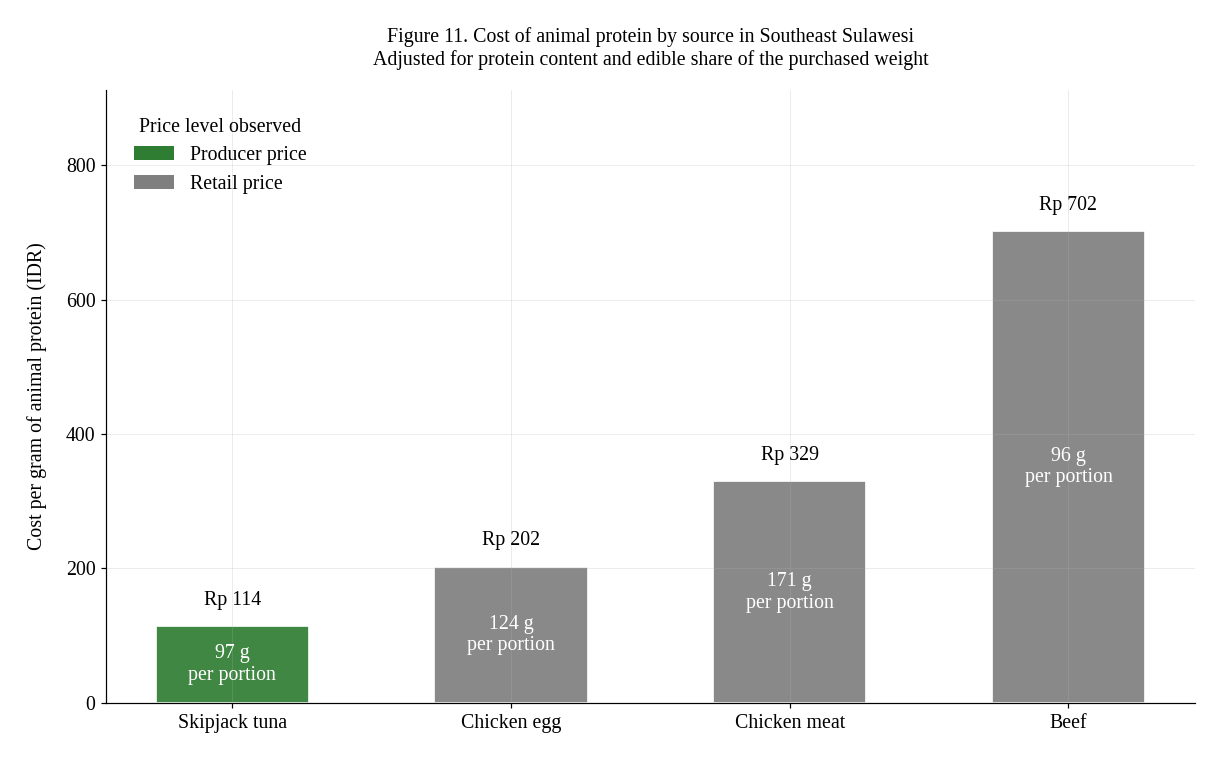

In [ ]:
urut = PROTEIN.sort_values("Cost_IDR_per_g_protein")
warna = [WARNA["aksen"] if t == "Producer price" else WARNA["campuran"]
         for t in urut.Price_level]

fig, sb = plt.subplots(figsize=(11.0, 6.8))
posisi = np.arange(len(urut))
sb.bar(posisi, urut.Cost_IDR_per_g_protein, width=0.55, color=warna, alpha=0.92,
       edgecolor="white", linewidth=1.2)
sb.set_xticks(posisi)
sb.set_xticklabels(urut.Source)
sb.set_ylabel("Cost per gram of animal protein (IDR)", labelpad=12)
sb.set_title("Figure 11. Cost of animal protein by source in Southeast Sulawesi\n"
             "Adjusted for protein content and edible share of the purchased weight",
             pad=16)
sb.set_ylim(0, urut.Cost_IDR_per_g_protein.max() * 1.30)

for i, (_, r) in enumerate(urut.iterrows()):
    sb.text(i, r.Cost_IDR_per_g_protein + urut.Cost_IDR_per_g_protein.max() * 0.035,
            "Rp %.0f" % r.Cost_IDR_per_g_protein, ha="center", va="bottom", fontsize=13)
    sb.text(i, r.Cost_IDR_per_g_protein * 0.5,
            "%.0f g\nper portion" % r.Grams_for_18g_protein, ha="center", va="center",
            fontsize=13, color="white")

penanda = [matplotlib.patches.Patch(facecolor=WARNA["aksen"], label="Producer price"),
           matplotlib.patches.Patch(facecolor=WARNA["campuran"], label="Retail price")]
sb.legend(handles=penanda, loc="upper left", borderaxespad=1.0,
          title="Price level observed", title_fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(JALUR["03_gambar"], "figure11_protein_cost.png"))
plt.show()

### Gambar kesepuluh, perbandingan hasil tahap pertama dan tahap kedua

Grafik membandingkan besaran utama sebelum dan sesudah kalibrasi. Tujuannya bukan
menunjukkan bahwa tahap kedua lebih besar atau lebih kecil, melainkan menunjukkan besaran
mana yang berubah dan besaran mana yang bertahan. Kesimpulan yang bertahan setelah
parameternya diganti adalah kesimpulan yang layak dibawa ke naskah.


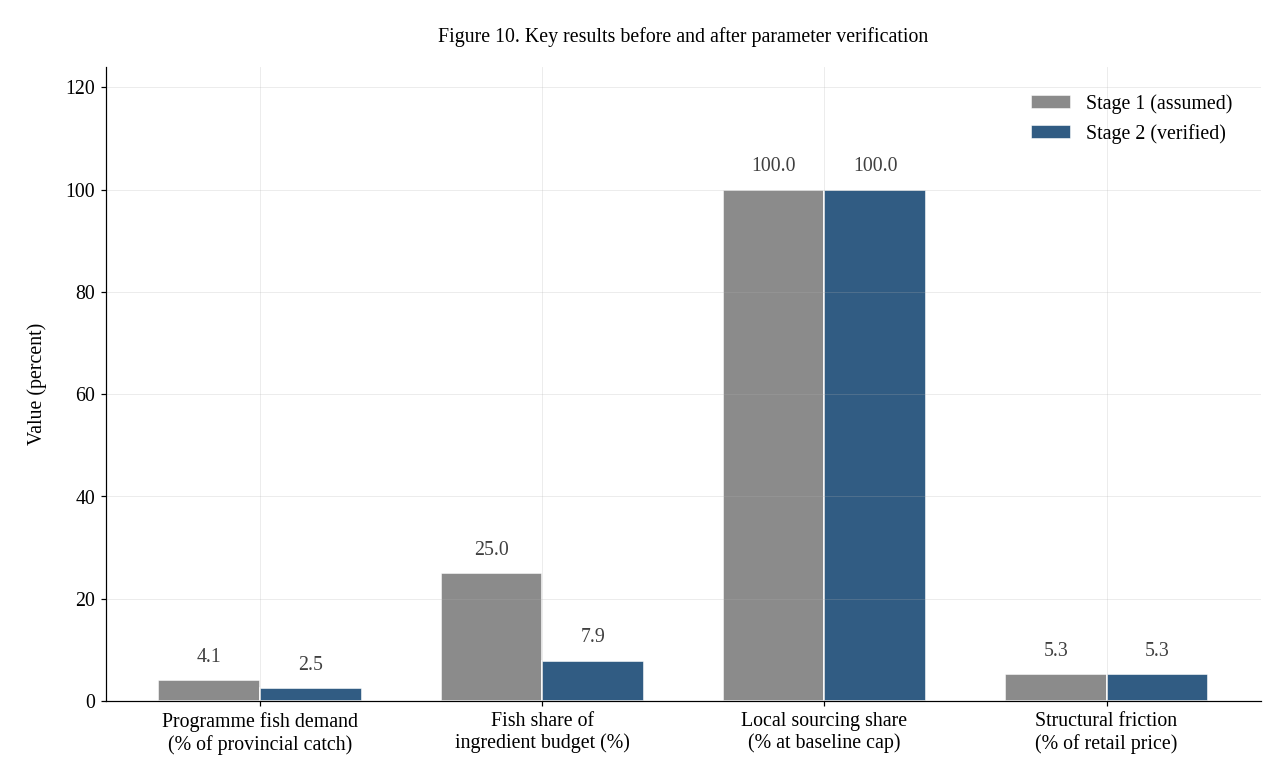

In [ ]:
lama = CATATAN_T1.get("hasil_utama", {})
banding = pd.DataFrame([
    dict(Metric="Programme fish demand\n(% of provincial catch)",
         Stage1=lama.get("kebutuhan_terhadap_produksi_persen", np.nan),
         Stage2=RASIO * 100),
    dict(Metric="Fish share of\ningredient budget (%)",
         Stage1=25.0, Stage2=PANGSA_IKAN_TURUNAN * 100),
    dict(Metric="Local sourcing share\n(% at baseline cap)",
         Stage1=(lama.get("pangsa_lokal_skenario_dasar", np.nan) or 0) * 100,
         Stage2=DASAR["pangsa_lokal"] * 100),
    dict(Metric="Structural friction\n(% of retail price)",
         Stage1=lama.get("biaya_friksi_struktural_persen", np.nan),
         Stage2=FRIKSI_PCT),
]).set_index("Metric")

fig, sb = plt.subplots(figsize=(11.6, 7.0))
posisi = np.arange(len(banding)); lebar = 0.36
b1 = sb.bar(posisi - lebar / 2, banding.Stage1, lebar, label="Stage 1 (assumed)",
            color=WARNA["campuran"], alpha=0.9, edgecolor="white", linewidth=1.1)
b2 = sb.bar(posisi + lebar / 2, banding.Stage2, lebar, label="Stage 2 (verified)",
            color=WARNA["struktural"], alpha=0.92, edgecolor="white", linewidth=1.1)
sb.set_xticks(posisi)
sb.set_xticklabels(banding.index, fontsize=13)
sb.set_ylabel("Value (percent)", labelpad=12)
sb.set_title("Figure 10. Key results before and after parameter verification", pad=16)
sb.set_ylim(0, max(banding.max()) * 1.24)
for kel in (b1, b2):
    for b in kel:
        if not np.isnan(b.get_height()):
            sb.text(b.get_x() + b.get_width() / 2, b.get_height() + max(banding.max()) * 0.026,
                    "%.1f" % b.get_height(), ha="center", va="bottom", fontsize=13,
                    color=WARNA["netral"])
sb.legend(loc="upper right", borderaxespad=1.0)
plt.tight_layout()
fig.savefig(os.path.join(JALUR["03_gambar"], "figure10_stage_comparison.png"))
plt.show()

banding.round(2).to_csv(os.path.join(JALUR["02_tabel"], "table15_stage_comparison.csv"))

## Langkah 5. Interpretasi otomatis tahap kedua

Seperti pada tahap pertama, interpretasi disusun oleh fungsi yang membaca hasil numerik dan
menerapkan aturan ambang yang tertulis dalam kode. Tambahannya, tahap kedua juga menilai
apakah setiap kesimpulan tahap pertama bertahan, berubah besarannya, atau gugur.


In [ ]:
def rupiah(x, bagi=1e12, satuan="triliun"):
    return "Rp%.3f %s" % (x / bagi, satuan)

def putusan(lama_nilai, baru_nilai, ambang=0.15):
    if lama_nilai is None or (isinstance(lama_nilai, float) and np.isnan(lama_nilai)):
        return "baru"
    beda = abs(baru_nilai - lama_nilai) / max(abs(lama_nilai), 1e-9)
    return "bertahan" if beda <= ambang else "berubah"

def teks_interpretasi():
    b = []
    b.append("HASIL KALIBRASI PARAMETER")
    b.append("")
    n_resmi = int((TABEL_PARAMETER.tingkat == "Resmi").sum())
    n_turunan = int((TABEL_PARAMETER.tingkat == "Turunan").sum())
    n_asumsi = int((TABEL_PARAMETER.tingkat == "Asumsi").sum())
    b.append("Dari %d parameter yang dipakai, %d berasal dari sumber resmi, %d merupakan "
             "turunan yang dapat ditelusuri, dan %d masih berupa asumsi rancangan. Pada "
             "tahap pertama terdapat tiga asumsi tanpa sumber, dan kini tersisa %d yang "
             "seluruhnya diuji melalui analisis kepekaan."
             % (len(TABEL_PARAMETER), n_resmi, n_turunan, n_asumsi, n_asumsi))
    b.append("")
    b.append("Penyusunan ulang aritmatika anggaran nasional menghasilkan simpangan "
             "terbesar %.1f persen terhadap angka yang disebutkan pejabat berwenang, "
             "sehingga kisaran hari layanan %d sampai %d hari setahun dapat dipakai."
             % (simpangan, P["hari_layanan_min"], P["hari_layanan_maks"]))
    b.append("")
    b.append("Koreksi terbesar terjadi pada berat ikan per porsi. Standar protein hewani "
             "%d sampai %d gram menuntut %.0f sampai %.0f gram ikan utuh, sedangkan tahap "
             "pertama memakai 50 gram. Angka lama terlalu rendah sekitar %.1f kali."
             % (P["protein_hewani_min"], P["protein_hewani_maks"], m_utuh_min,
                m_utuh_maks, m_utuh_min / 50))
    b.append("")
    b.append("=" * 76)
    b.append("")
    b.append("UJI KETAHANAN KESIMPULAN")
    b.append("")
    lama_rasio = lama.get("kebutuhan_terhadap_produksi_persen", np.nan)
    b.append("Kesimpulan pertama menyatakan kapasitas pasokan bukan kendala yang mengikat. "
             "Pada kisi kepekaan dengan frekuensi menu ikan %d sampai %d persen dan berat "
             "%d sampai %d gram, kebutuhan tertinggi hanya mencapai %.2f persen produksi "
             "provinsi."
             % (min(FREKUENSI) * 100, max(FREKUENSI) * 100, min(GRAM), max(GRAM),
                KISI.values.max()))
    if KISI.values.max() < 25:
        b.append("Tidak ada satu pun kombinasi wajar yang mendekati batas kapasitas, "
                 "sehingga kesimpulan pertama bertahan dengan margin yang lebar.")
    elif KISI.values.max() < 100:
        b.append("Seluruh kombinasi masih berada di bawah kapasitas, namun marginnya "
                 "tidak selebar yang diperkirakan pada tahap pertama.")
    else:
        b.append("Terdapat kombinasi yang melampaui kapasitas, sehingga kesimpulan "
                 "pertama tidak dapat dipertahankan tanpa syarat.")
    b.append("")
    b.append("Kesimpulan kedua tahap pertama menyatakan terdapat marjin rantai pasok "
             "sebesar %.1f persen. Kesimpulan itu gugur. Pemeriksaan konsistensi "
             "menunjukkan bahwa pangsa ikan dalam anggaran tidak dapat diasumsikan bebas, "
             "karena terikat pada frekuensi menu, berat porsi, dan harga."
             % lama.get("marjin_rantai_pasok_persen", np.nan))
    b.append("Asumsi pangsa dua puluh lima persen mensyaratkan menu ikan hadir pada %.0f "
             "persen hari layanan. Angka itu %s, karena petunjuk teknis mewajibkan "
             "rotasi siklus menu sehingga satu jenis lauk tidak mungkin hadir hampir "
             "setiap hari." % (frekuensi_tersirat * 100, VONIS))
    b.append("Metrik penggantinya adalah pangsa nilai ikan yang diturunkan, sebesar %.1f "
             "persen anggaran bahan baku. Angka ini tidak memuat asumsi bebas dan "
             "menunjukkan bahwa komoditas unggulan provinsi baru menyerap sebagian kecil "
             "belanja bahan baku programnya sendiri." % (PANGSA_IKAN_TURUNAN * 100))
    b.append("")
    b.append("Perbandingan biaya protein memperkuat hal tersebut. Pada perhitungan yang "
             "sudah disesuaikan dengan kandungan protein dan bagian yang dapat dimakan, "
             "%s merupakan sumber protein hewani dengan biaya terendah, yaitu Rp%.0f per "
             "gram protein." % (termurah.Source, termurah.Cost_IDR_per_g_protein))
    b.append("")
    b.append("Kesimpulan lapis pertama dan lapis kedua tidak tersentuh kalibrasi ini "
             "karena keduanya dihitung langsung dari data harga dan tidak memakai satu pun "
             "parameter program. Taksonomi friksi dan indeks konektivitas tetap seperti "
             "pada tahap pertama.")
    b.append("")
    b.append("=" * 76)
    b.append("")
    b.append("KEPADATAN PEMASOK")
    b.append("")
    b.append("Rasio pemasok terhadap dapur di Sulawesi Tenggara sebesar %.2f pada posisi "
             "Juli 2026, sedangkan ambang yang ditetapkan adalah %d pemasok per dapur. "
             "Agar ambang terpenuhi setiap pemasok harus melayani rata rata %.1f dapur."
             % (akhir["Suppliers per kitchen"], P["pemasok_minimum"],
                akhir["Kitchens per supplier to meet threshold"]))
    b.append("Perlu ditegaskan bahwa rasio ini bukan jumlah pemasok per dapur, karena satu "
             "pemasok dapat melayani beberapa dapur sekaligus. Yang ditunjukkan angka ini "
             "adalah tipisnya basis pemasok yang tersedia, bukan pelanggaran ketentuan.")
    b.append("")
    b.append("Antara April dan Juli 2026 basis pemasok tumbuh %.1f persen sedangkan jumlah "
             "dapur tumbuh %.1f persen, sehingga kepadatan pemasok membaik dari %.2f "
             "menjadi %.2f."
             % (pertumbuhan_pemasok * 100, pertumbuhan_dapur * 100,
                PASOK["Suppliers per kitchen"].iloc[0],
                PASOK["Suppliers per kitchen"].iloc[-1]))
    b.append("Pemanfaatan kapasitas dapur baru %.1f persen dari kapasitas rancangan, "
             "sehingga kebutuhan bahan baku masih akan bertambah seiring dapur terisi "
             "penuh." % (akhir["Capacity utilisation"] * 100))
    b.append("")
    b.append("=" * 76)
    b.append("")
    b.append("ANGKA UNTUK NASKAH")
    b.append("")
    b.append("Penerima manfaat Sulawesi Tenggara : %s orang per 31 Juli 2026"
             % format(int(P["penerima_sultra"]), ","))
    b.append("Dapur yang beroperasi              : %d unit di 17 kabupaten dan kota"
             % P["sppg_sultra"])
    b.append("Pemasok terdaftar                  : %s" % format(int(P["pemasok_sultra"]), ","))
    b.append("Anggaran bahan baku setahun        : %s sampai %s"
             % (rupiah(ANG_BAHAN_MIN), rupiah(ANG_BAHAN_MAK)))
    b.append("Kebutuhan ikan skenario dasar      : %s ton setara %.2f persen produksi"
             % (format(KEBUTUHAN_DASAR, ",.0f"), RASIO * 100))
    b.append("Tarif friksi struktural            : Rp%s per kilogram"
             % format(TARIF_FRIKSI, ",.0f"))
    b.append("Pangsa ikan dalam anggaran bahan   : %.1f persen (diturunkan, bukan diasumsikan)"
             % (PANGSA_IKAN_TURUNAN * 100))
    b.append("Biaya protein termurah             : Rp%.0f per gram dari %s"
             % (termurah.Cost_IDR_per_g_protein, termurah.Source))
    return "\n".join(b)

INTERPRETASI2 = teks_interpretasi()
print(INTERPRETASI2)
with open(os.path.join(JALUR["04_interpretasi"], "interpretasi_tahap2.txt"), "w",
          encoding="utf-8") as f:
    f.write(INTERPRETASI2)

HASIL KALIBRASI PARAMETER

Dari 19 parameter yang dipakai, 16 berasal dari sumber resmi, 1 merupakan turunan yang dapat ditelusuri, dan 2 masih berupa asumsi rancangan. Pada tahap pertama terdapat tiga asumsi tanpa sumber, dan kini tersisa 2 yang seluruhnya diuji melalui analisis kepekaan.

Penyusunan ulang aritmatika anggaran nasional menghasilkan simpangan terbesar 3.6 persen terhadap angka yang disebutkan pejabat berwenang, sehingga kisaran hari layanan 240 sampai 252 hari setahun dapat dipakai.

Koreksi terbesar terjadi pada berat ikan per porsi. Standar protein hewani 15 sampai 20 gram menuntut 81 sampai 108 gram ikan utuh, sedangkan tahap pertama memakai 50 gram. Angka lama terlalu rendah sekitar 1.6 kali.


UJI KETAHANAN KESIMPULAN

Kesimpulan pertama menyatakan kapasitas pasokan bukan kendala yang mengikat. Pada kisi kepekaan dengan frekuensi menu ikan 20 sampai 60 persen dan berat 80 sampai 120 gram, kebutuhan tertinggi hanya mencapai 6.10 persen produksi provinsi.
Tidak ada s

## Langkah 6. Daftar pustaka tambahan tahap kedua

Rujukan berikut melengkapi daftar pustaka tahap pertama. Seluruhnya merupakan sumber
primer berupa dokumen resmi, siaran pers lembaga, atau pemberitaan kantor berita nasional
yang mengutip pejabat berwenang beserta jabatannya.


In [ ]:
PUSTAKA2 = [
 dict(sitasi="Badan Gizi Nasional. (2025). Petunjuk teknis tata kelola penyelenggaraan "
             "Program Makan Bergizi Gratis tahun anggaran 2026 (Keputusan Kepala Badan "
             "Gizi Nasional Nomor 401.1 Tahun 2025).",
      tautan="https://www.bgn.go.id/juknis",
      jenis="Dokumen resmi",
      pakai="Struktur biaya per porsi, insentif fasilitas, dan acuan penyusunan menu"),
 dict(sitasi="Badan Gizi Nasional. (2026). BGN ingatkan anggaran bahan makan MBG "
             "Rp8.000 sampai Rp10.000, bukan Rp15.000 (Siaran Pers Nomor "
             "SIPERS-98/BGN/02/2026).",
      tautan="https://www.bgn.go.id/news/siaran-pers/"
             "bgn-ingatkan-anggaran-bahan-makan-mbg-rp8000-rp10000-bukan-rp15000",
      jenis="Siaran pers resmi",
      pakai="Rincian komponen bahan baku, operasional, dan fasilitas per porsi"),
 dict(sitasi="Badan Gizi Nasional. (2026). Menu MBG disusun sesuai standar AKG Kemenkes.",
      tautan="https://www.bgn.go.id/news/artikel/menu-mbg-disusun-sesuai-standar-akg-kemenkes",
      jenis="Artikel resmi lembaga",
      pakai="Dasar rujukan standar Angka Kecukupan Gizi dalam penyusunan menu"),
 dict(sitasi="Kantor Wilayah Direktorat Jenderal Perbendaharaan Provinsi Sulawesi "
             "Tenggara. (2026). Laporan pemantauan Program Makan Bergizi Gratis lingkup "
             "Sulawesi Tenggara periode April 2026.",
      tautan="https://djpb.kemenkeu.go.id/kanwil/sultra/id/data-publikasi/berita-terbaru/"
             "3410-laporan-pemantauan-program-makan-bergizi-gratis-mbg-lingkup-sulawesi-"
             "tenggara-periode-april-2026.html",
      jenis="Laporan resmi",
      pakai="Capaian program posisi April 2026 yang dipakai pada tahap pertama"),
 dict(sitasi="ANTARA. (2026, 12 Agustus). DJPb sebut program MBG di Sultra jangkau 704 "
             "ribu penerima manfaat per akhir Juli 2026.",
      tautan="https://sultra.antaranews.com/berita/538793/"
             "djpb-sebut-program-mbg-di-sultra-jangkau-704-penerima-manfaat-per-akhir-juli-2026",
      jenis="Kantor berita nasional",
      pakai="Capaian terbaru dan pernyataan Kepala Kanwil DJPb mengenai rantai pasok "
            "serta tantangan distribusi kepulauan"),
 dict(sitasi="Kementerian Kesehatan Republik Indonesia. Tabel Komposisi Pangan Indonesia.",
      tautan="https://www.kemkes.go.id",
      jenis="Dokumen resmi",
      pakai="Kandungan protein ikan tongkol segar per seratus gram"),
 dict(sitasi="Badan Pangan Nasional. Tabel Komposisi Pangan Segar Indonesia.",
      tautan="https://badanpangan.go.id/tabel-komposisi-pangan-segar-indonesia",
      jenis="Basis data resmi",
      pakai="Pembanding kandungan gizi pangan segar"),
]

def susun2():
    b = ["DAFTAR PUSTAKA TAMBAHAN TAHAP KEDUA", ""]
    for i, p in enumerate(sorted(PUSTAKA2, key=lambda d: d["sitasi"]), 1):
        b += ["%d. %s" % (i, p["sitasi"]),
              "   Tautan: %s" % p["tautan"],
              "   Jenis sumber: %s" % p["jenis"],
              "   Dipakai untuk: %s" % p["pakai"], ""]
    b += ["", "CATATAN",
          "",
          "Seluruh angka program pada tahap kedua berasal dari sumber di atas. Angka",
          "capaian daerah diambil dari otoritas perbendaharaan yang memang bertugas",
          "mencatat penyaluran dana, bukan dari pemberitaan umum. Angka struktur biaya",
          "diambil dari siaran pers resmi lembaga penyelenggara beserta nomor dokumennya.",
          "",
          "Angka hari layanan tidak diterbitkan sebagai ketetapan tunggal melainkan",
          "sebagai kisaran, sehingga dipakai sebagai kisaran pula dan diuji ulang melalui",
          "penyusunan ulang aritmatika anggaran nasional."]
    return "\n".join(b)

PUSTAKA_TEKS = susun2()
print(PUSTAKA_TEKS)
with open(os.path.join(JALUR["05_pustaka"], "daftar_pustaka_tahap2.txt"), "w",
          encoding="utf-8") as f:
    f.write(PUSTAKA_TEKS)
pd.DataFrame(PUSTAKA2).to_csv(os.path.join(JALUR["05_pustaka"], "pustaka_tahap2.csv"),
                              index=False)

DAFTAR PUSTAKA TAMBAHAN TAHAP KEDUA

1. ANTARA. (2026, 12 Agustus). DJPb sebut program MBG di Sultra jangkau 704 ribu penerima manfaat per akhir Juli 2026.
   Tautan: https://sultra.antaranews.com/berita/538793/djpb-sebut-program-mbg-di-sultra-jangkau-704-penerima-manfaat-per-akhir-juli-2026
   Jenis sumber: Kantor berita nasional
   Dipakai untuk: Capaian terbaru dan pernyataan Kepala Kanwil DJPb mengenai rantai pasok serta tantangan distribusi kepulauan

2. Badan Gizi Nasional. (2025). Petunjuk teknis tata kelola penyelenggaraan Program Makan Bergizi Gratis tahun anggaran 2026 (Keputusan Kepala Badan Gizi Nasional Nomor 401.1 Tahun 2025).
   Tautan: https://www.bgn.go.id/juknis
   Jenis sumber: Dokumen resmi
   Dipakai untuk: Struktur biaya per porsi, insentif fasilitas, dan acuan penyusunan menu

3. Badan Gizi Nasional. (2026). BGN ingatkan anggaran bahan makan MBG Rp8.000 sampai Rp10.000, bukan Rp15.000 (Siaran Pers Nomor SIPERS-98/BGN/02/2026).
   Tautan: https://www.bgn.go.id/new

## Langkah 7. Menyimpan dan mengunduh arsip tahap kedua

In [ ]:
import scipy, sklearn

CATATAN2 = {
    "waktu_pengolahan": dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "arsip_tahap1": os.path.basename(ARSIP),
    "versi_pustaka": {"numpy": np.__version__, "pandas": pd.__version__,
                      "scipy": scipy.__version__, "matplotlib": matplotlib.__version__},
    "parameter_resmi": {d["kode"]: d["nilai"] for d in PARAMETER
                        if d["tingkat"] == "Resmi"},
    "parameter_turunan": {d["kode"]: d["nilai"] for d in PARAMETER
                          if d["tingkat"] == "Turunan"},
    "asumsi_tersisa": {d["kode"]: d["nilai"] for d in PARAMETER
                       if d["tingkat"] == "Asumsi"},
    "hasil_tahap2": {
        "kebutuhan_ikan_ton": round(float(KEBUTUHAN_DASAR), 1),
        "kebutuhan_terhadap_produksi_persen": round(float(RASIO * 100), 2),
        "kepekaan_maksimum_persen": round(float(KISI.values.max()), 2),
        "anggaran_bahan_baku_min_rp": round(float(ANG_BAHAN_MIN), 0),
        "anggaran_bahan_baku_maks_rp": round(float(ANG_BAHAN_MAK), 0),
        "pangsa_ikan_anggaran_turunan_persen": round(float(PANGSA_IKAN_TURUNAN * 100), 2),
        "frekuensi_tersirat_asumsi_lama_persen": round(float(frekuensi_tersirat * 100), 1),
        "vonis_asumsi_lama": VONIS,
        "batas_serapan_titik_jenuh": round(float(BATAS_DASAR), 3),
        "biaya_protein_termurah_rp_per_gram": round(float(termurah.Cost_IDR_per_g_protein), 1),
        "tarif_friksi_rp_kg": round(float(TARIF_FRIKSI), 0),
        "pemasok_per_dapur": round(float(akhir["Suppliers per kitchen"]), 2),
        "pemanfaatan_kapasitas_dapur": round(float(akhir["Capacity utilisation"]), 3),
        "simpangan_rekonstruksi_anggaran_persen": round(float(simpangan), 1),
    },
    "batasan_tersisa": [
        "Frekuensi kemunculan menu ikan tidak diatur dalam ketetapan angka sehingga "
        "diuji melalui kisi kepekaan.",
        "Harga ikan tercatat pada tingkat produsen sedangkan harga sumber protein lain "
        "pada tingkat eceran, sehingga perbandingan biaya protein belum setara.",
        "Bagian dapat dimakan daging ayam ras mengacu pada karkas dan perlu "
        "dikonfirmasi sebelum dipakai dalam naskah.",
        "Bagian dapat dimakan ikan utuh memakai kisaran lazim dan diuji pada kisi.",
        "Data produksi perikanan menurut kabupaten hanya lengkap pada tahun %d sehingga "
        "dipakai sebagai pola sebaran." % tahun_ikan,
    ],
}
with open(os.path.join(JALUR["04_interpretasi"], "catatan_teknis_tahap2.json"), "w",
          encoding="utf-8") as f:
    json.dump(CATATAN2, f, indent=2, ensure_ascii=False)
print(json.dumps(CATATAN2["hasil_tahap2"], indent=2, ensure_ascii=False))

{
  "kebutuhan_ikan_ton": 5196.0,
  "kebutuhan_terhadap_produksi_persen": 2.54,
  "kepekaan_maksimum_persen": 6.1,
  "anggaran_bahan_baku_min_rp": 1385601888000.0,
  "anggaran_bahan_baku_maks_rp": 1732002360000.0,
  "pangsa_ikan_anggaran_turunan_persen": 7.91,
  "frekuensi_tersirat_asumsi_lama_persen": 94.8,
  "vonis_asumsi_lama": "bertentangan dengan kewajiban rotasi menu",
  "batas_serapan_titik_jenuh": 0.03,
  "biaya_protein_termurah_rp_per_gram": 113.7,
  "tarif_friksi_rp_kg": 1117.0,
  "pemasok_per_dapur": 6.98,
  "pemanfaatan_kapasitas_dapur": 0.832,
  "simpangan_rekonstruksi_anggaran_persen": 3.6
}


In [ ]:
NAMA = "SIMPUL_Forkestra2026_tahap2_%s" % dt.datetime.now().strftime("%Y%m%d_%H%M")
tujuan = os.path.join("/content" if DI_COLAB else os.getcwd(), NAMA + ".zip")

jumlah = 0
with zipfile.ZipFile(tujuan, "w", zipfile.ZIP_DEFLATED) as z:
    for akar, _, berkas in os.walk(JALUR["akar"]):
        if "01_masukan" in akar:
            continue
        for nama in berkas:
            if nama.lower().endswith(".zip"):
                continue
            penuh = os.path.join(akar, nama)
            z.write(penuh, os.path.relpath(penuh, JALUR["akar"]))
            jumlah += 1

print("Arsip tahap kedua selesai.")
print("  Nama   :", os.path.basename(tujuan))
print("  Isi    : %d berkas" % jumlah)
print("  Ukuran : %.2f megabita" % (os.path.getsize(tujuan) / 1e6))

salinan = os.path.join(JALUR["akar"], os.path.basename(tujuan))
if os.path.abspath(salinan) != os.path.abspath(tujuan):
    shutil.copy2(tujuan, salinan)
    print("  Salinan:", salinan)

if DI_COLAB:
    from google.colab import files
    files.download(tujuan)
    print("\nUnduhan dimulai secara otomatis.")
else:
    print("\nDi luar Colab, arsip tersedia pada:", tujuan)

Arsip tahap kedua selesai.
  Nama   : SIMPUL_Forkestra2026_tahap2_20260821_1646.zip
  Isi    : 16 berkas
  Ukuran : 0.55 megabita
  Salinan: /content/drive/MyDrive/SIMPUL_Forkestra2026_Tahap2/SIMPUL_Forkestra2026_tahap2_20260821_1646.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Unduhan dimulai secara otomatis.


### Penutup

Tahap kedua menutup tiga celah yang tersisa dari tahap pertama. Hari layanan kini memiliki
sumber berupa pernyataan pejabat berwenang yang aritmatikanya sudah diperiksa ulang. Berat
ikan per porsi kini diturunkan dari standar gizi, bukan ditebak. Frekuensi menu ikan yang
memang tidak diatur kini diperlakukan sebagai peubah kebijakan yang diuji dalam kisi, bukan
disembunyikan sebagai asumsi tunggal.

Kesimpulan pokok tahap pertama bertahan. Kapasitas pasokan bukan kendala, dan persoalan
sesungguhnya terletak pada pencocokan serta keandalan pengiriman. Yang berubah hanyalah
besaran, bukan arah.

Berkas keluaran siap dipakai untuk menyusun naskah bersama keluaran tahap pertama.
